##Imports

In [ ]:
# Data Manipulation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

# Evaluation
from sklearn.metrics import silhouette_score

##Data Loading

In [5]:
df=pd.read_csv('/content/single_genre_artists.csv')

In [6]:
df.shape

#(95837, 23)

(95837, 23)

In [7]:
df

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.1840,4,...,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.1800,10,...,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.2060,0,...,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.4670,9,...,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.2980,9,...,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,...,0.116,0.000000,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,...,0.143,0.000000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,...,0.996,0.973000,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,...,0.996,0.961000,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55


In [8]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [9]:
df.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


In [10]:
df.describe(include='object')

,id_songs,name_song,id_artists,release_date,genres,name_artists
count,95837,95837,95837,95837,95837,95837
unique,95837,85427,18009,10436,3153,17662
top,5rgu12WBIHQtvej2MdHSH0,Bibi Blocksberg Lied,3meJIgRw7YleJrmbpbJK6S,1983,['hoerspiel'],Die drei ???
freq,1,33,3856,754,8027,3856


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

##Data Preprocessing

##Handling Null Values

In [12]:
df.isna().sum()

,0
id_songs,0
name_song,0
popularity_songs,0
duration_ms,0
explicit,0
id_artists,0
release_date,0
danceability,0
energy,0
key,0


##Checking for Duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

##Checking Datatypes


In [14]:
df.dtypes

,0
id_songs,object
name_song,object
popularity_songs,int64
duration_ms,int64
explicit,int64
id_artists,object
release_date,object
danceability,float64
energy,float64
key,int64


##Feature Selection

In [15]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [16]:
#Dropping Unnecessary Columns

df = df.drop(['id_songs','name_song','name_artists'],axis=1)
df.columns

Index(['popularity_songs', 'duration_ms', 'explicit', 'id_artists',
       'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'popularity_artists'],
      dtype='object')

In [17]:
#Selecting Features for Clustering Analysis

features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_ms']

X = df[features]

In [18]:
X.columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')

##Feature Scaling

In [19]:
SC= StandardScaler()

In [20]:
X_Scaled =SC.fit_transform(X)
X_Scaled

array([[-0.15347598, -1.51112816, -0.75790895, ...,  0.32128698,
         0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, ..., -0.57745518,
        -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, ..., -0.37594348,
        -1.56000306, -0.00394925],
       ...,
       [ 0.14249425, -2.21700341, -3.87787243, ...,  1.27242218,
        -1.62041993, -1.07201656],
       [-0.15991012, -2.14971674, -3.24149759, ..., -0.7588157 ,
        -1.78348586, -0.19941949],
       [-0.17277839, -0.09768491,  0.56580125, ..., -1.46410663,
         0.47552221,  0.4206722 ]])

In [21]:
pd.DataFrame(X_Scaled,columns=features)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-0.401735
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,0.124906
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,-0.003949
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,-0.397437
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,-0.346143
...,...,...,...,...,...,...,...,...,...,...
95832,0.560713,0.113908,0.800599,-0.464870,-1.038056,-0.353405,-0.322428,0.264864,1.608703,-0.288165
95833,-0.378671,0.558254,1.372746,-0.499000,-0.956340,-0.353405,-0.678133,-1.117507,0.414907,0.485036
95834,0.142494,-2.217003,-3.877872,-0.184566,1.625267,3.832648,-0.629163,1.272422,-1.620420,-1.072017
95835,-0.159910,-2.149717,-3.241498,-0.239029,1.625267,3.781021,-0.613019,-0.758816,-1.783486,-0.199419


##Finding Optimal Number Of Cluster using Elbow Method

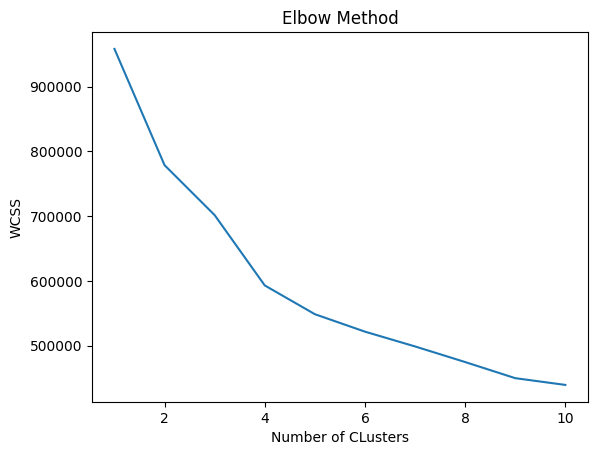

In [22]:
#Elbow method

wcss = []

for i in range(1,11):
  kmeans=KMeans(n_clusters=i,n_init='auto',random_state=0)
  kmeans.fit(X_Scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of CLusters')
plt.ylabel('WCSS')
plt.show()


Using the Elbow Method, the optimal number of clusters appears around k=4.However, k=5 was also evaluated for better granularity.Final selection was confirmed using Silhouette Score.

# KMeans Silhouette Score for 4 and 5 clusters

In [29]:
results = {}

for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
    kmeans.fit(X_Scaled)
    score = silhouette_score(X_Scaled, kmeans.labels_, sample_size=10000, random_state=0)
    results[k] = score

print(results)

{4: np.float64(0.2332835644174628), 5: np.float64(0.1871092186564943)}


##Hierarchical CLustering

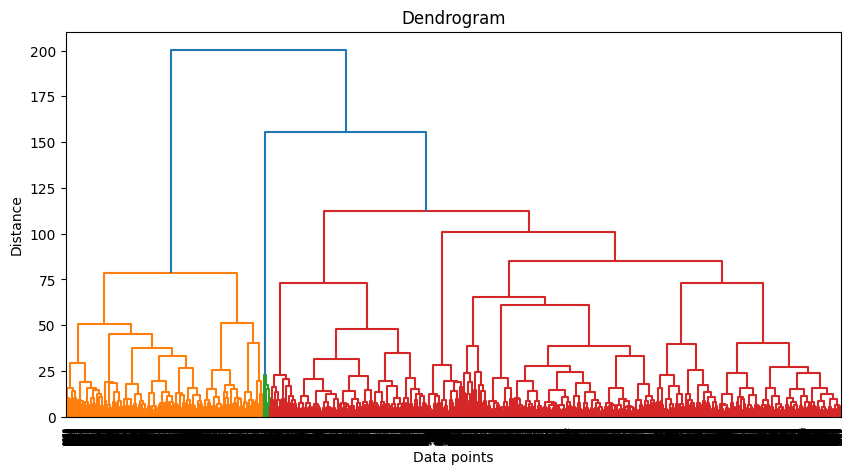

In [30]:
#Dendrogram

linked = linkage(X_Scaled[:10000], method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

The optimal number of clusters was determined using both the Elbow method and silhouette analysis. The Elbow method suggested a possible range of 4 to 5 clusters, which was further evaluated using silhouette scores. The silhouette score was higher for k=4 compared to k=5, indicating better cluster separation.

To further validate this, hierarchical clustering was performed, and the dendrogram also indicated the presence of four distinct clusters. Although hierarchical clustering produced a lower silhouette score (0.14), it confirmed the cluster structure observed in K-Means.

Therefore, k=4 was selected as the optimal number of clusters, and K-Means was chosen as the final clustering algorithm due to its superior performance.


In [ ]:
#Hierarchical Clustering

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_Scaled[:10000])

In [ ]:
#Hierarchical CLustering Silhouette Score

silhouette_score(X_Scaled[:10000], labels_agg)

np.float64(0.14796129429220084)

##KMeans Clustering

In [44]:
# Final KMeans model with optimal k=4

kmeans = KMeans(n_clusters=4, n_init='auto', random_state=0)

kmeans.fit(X_Scaled)

labels_kmeans = kmeans.labels_

df['Predicted_Cluster'] = labels_kmeans

print("KMeans clustering completed with k=4")

KMeans clustering completed with k=4


In [38]:
df

,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,Predicted_Cluster
0,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.1840,4,-13.757,1,...,0.993,0.000016,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],22,1
1,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.1800,10,-15.375,1,...,0.989,0.000000,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],22,1
2,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.2060,0,-15.514,1,...,0.995,0.000000,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],22,1
3,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.4670,9,-12.393,0,...,0.991,0.000000,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],22,1
4,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.2980,9,-13.806,1,...,0.991,0.000000,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],22,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,-6.356,1,...,0.116,0.000000,0.1650,0.640,166.107,4,16057.0,['alt z'],56,3
95833,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,-3.639,1,...,0.143,0.000000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],36,3
95834,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,-28.573,1,...,0.996,0.973000,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],52,0
95835,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,-25.551,1,...,0.996,0.961000,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],55,0


##DBSCAN Clustering

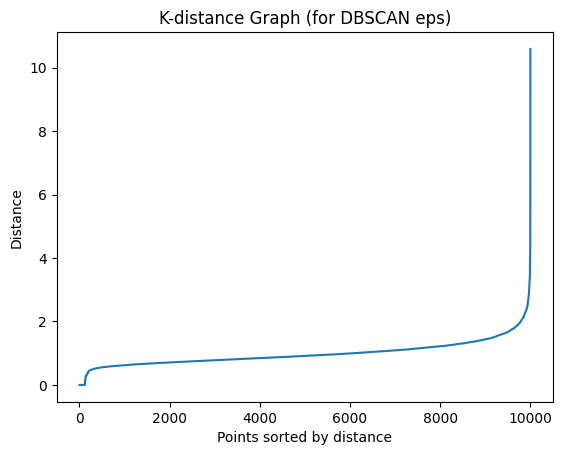

In [34]:
#K-Distance Graph

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_Scaled[:10000])

distances, indices = neighbors_fit.kneighbors(X_Scaled[:10000])

# sort distances
distances = np.sort(distances[:, 4])  # 4 = min_samples-1

plt.plot(distances)
plt.title("K-distance Graph (for DBSCAN eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.show()

In [35]:
#DBSCAN Clustering with the known eps value

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_Scaled[:10000])
set(labels_db)

{np.int64(-1),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14)}

In [36]:
#DBSCAN Clustering Silhouette Score

silhouette_score(X_Scaled[:10000], labels_db)

np.float64(-0.038446088710744994)

DBSCAN clustering was performed using an eps value derived from the k-distance graph. However, the algorithm resulted in multiple small clusters along with noise points and produced a negative silhouette score.

This indicates that the dataset does not exhibit clear density-based separation, which is required for DBSCAN to perform effectively. Therefore, DBSCAN was not suitable for this dataset and was not selected as the final model.


In [33]:
kmeans.cluster_centers_

array([[-0.65927367, -0.5898328 , -0.84678137, -0.39727614,  0.62822017,
         3.16355931, -0.21238117, -0.50059214, -0.13085641,  0.15912806],
       [-0.52498726, -0.96835189, -0.52840266, -0.38576549,  0.86963953,
        -0.27378541, -0.2453449 , -0.61378325, -0.21693371,  0.09820909],
       [ 0.49865718, -0.31475783, -0.67943007,  2.43394749,  0.38355481,
        -0.34966173,  1.1347022 ,  0.03603077, -0.57487693, -0.95598455],
       [ 0.76256893,  0.56654418,  0.46510143, -0.32884372, -0.45990592,
        -0.26127772, -0.28178295,  0.85980546,  0.02653449,  0.04156864],
       [-0.55770918,  0.70027137,  0.64071521, -0.35102367, -0.79521652,
        -0.23290994,  0.11103619, -0.38219512,  0.59930634,  0.32746868]])

The cluster centers obtained from K-Means were analyzed to understand the characteristics of each cluster. Since the values are standardized, positive values indicate higher-than-average feature values, while negative values indicate lower-than-average values.

Cluster 0 is characterized by low energy, low danceability, and higher acousticness, indicating calm and acoustic songs. These tracks are likely soft, less intense, and suitable for relaxed listening.

Cluster 1 shows high acousticness and positive valence but lower energy and loudness, suggesting pleasant, melodic, and emotionally uplifting songs with a softer tone.

Cluster 2 is dominated by very high speechiness, indicating the presence of spoken words or lyrical emphasis. This cluster likely represents rap, spoken-word, or dialogue-heavy tracks.

Cluster 3 exhibits high danceability, energy, and loudness, representing energetic and upbeat songs suitable for parties, workouts, or lively environments.

Overall, the clusters represent meaningful groupings of songs based on their audio features, allowing better understanding and categorization of music.


##Adding Cluster Label

In [42]:
# Create cluster label mapping

cluster_names = {
    0: "Calm / Acoustic Songs",
    1: "Melodic / Positive Songs",
    2: "Speech-heavy (Rap / Spoken)",
    3: "High Energy / Dance Songs"
}

# Add new column with labels
df['Cluster_Label'] = df['Predicted_Cluster'].map(cluster_names)

df[['Predicted_Cluster', 'Cluster_Label']].value_counts()

,,count
Predicted_Cluster,Cluster_Label,
3,High Energy / Dance Songs,46393
1,Melodic / Positive Songs,29164
2,Speech-heavy (Rap / Spoken),12412
0,Calm / Acoustic Songs,7868


##Visualizing the Clusters Using PCA

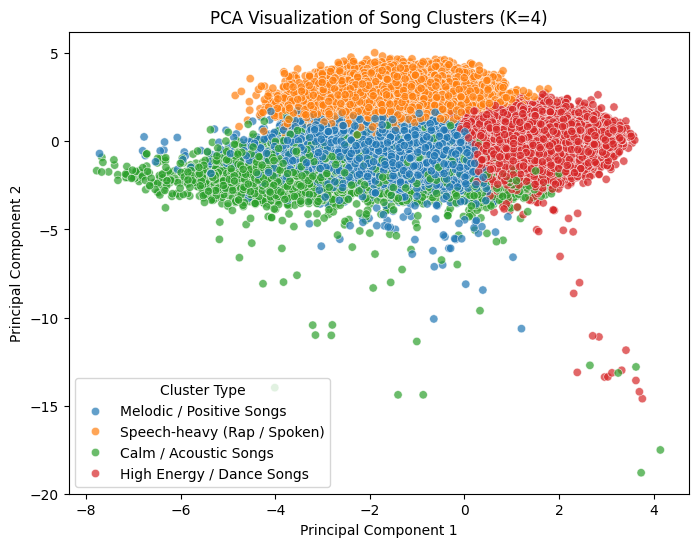

In [45]:
# Step 1: PCA transformation

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_Scaled)

# Step 2: Create PCA dataframe
PCA_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Step 3: Adding cluster labels
PCA_df['Cluster_Label'] = df['Cluster_Label']

# Step 4: Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=PCA_df,
    x='PC1',
    y='PC2',
    hue='Cluster_Label',   # labels instead of numbers
    palette='tab10',       # clear different colors
    alpha=0.7
)

plt.title("PCA Visualization of Song Clusters (K=4)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Type")
plt.show()

The PCA visualization of the clustered data shows that the K-Means algorithm has formed reasonably well-defined clusters. Certain clusters, particularly the high energy/dance songs and speech-heavy tracks, appear more compact and clearly separated from others, indicating strong similarity within those groups.

However, some overlap is observed, especially among the calm/acoustic songs and melodic/positive songs, suggesting that these categories share similar audio characteristics. This overlap is expected in music data, as song features often vary continuously rather than forming strictly distinct groups.

Overall, the visualization supports the clustering results, demonstrating that while clear patterns exist, there is a natural blending between certain types of songs, reflecting the complexity of musical features.


In [ ]:
########################################      DONE      ########################################